In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (55977, 2)


,Statement,Label
0,who praises india s aarogya setu app says it h...,1
1,in delhi deputy us secretary of state stephen ...,1
2,lac tensions china s strategy behind deliberat...,1
3,india has signed documents on space cooperatio...,1
4,tamil nadu chief minister s mother passes away at,1


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 55977 entries, 0 to 55976
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Statement  55977 non-null  str  
 1   Label      55977 non-null  int64
dtypes: int64(1), str(1)
memory usage: 874.8 KB
None


In [4]:
print(df["Label"].value_counts())

Label
1    37437
0    18540
Name: count, dtype: int64


In [5]:
print(df["Label"].value_counts(normalize=True) * 100)

Label
1    66.879254
0    33.120746
Name: proportion, dtype: float64


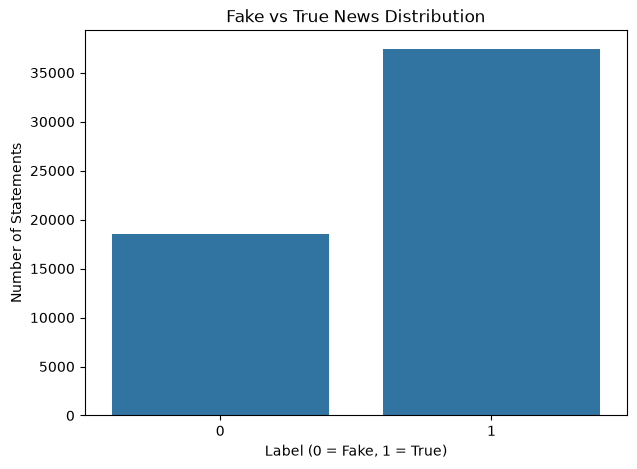

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df,x="Label")

plt.title("Fake vs True News Distribution")
plt.xlabel("Label (0 = Fake, 1 = True)")
plt.ylabel("Number of Statements")

plt.show()

In [7]:
df["character_count"] = df["Statement"].str.len()
df["word_count"] = df["Statement"].str.split().str.len()

display(df[["Statement", "character_count", "word_count", "Label"]].head())

,Statement,character_count,word_count,Label
0,who praises india s aarogya setu app says it h...,81,14,1
1,in delhi deputy us secretary of state stephen ...,82,14,1
2,lac tensions china s strategy behind deliberat...,74,11,1
3,india has signed documents on space cooperatio...,73,11,1
4,tamil nadu chief minister s mother passes away at,49,9,1


In [8]:
print(df["word_count"].describe())

count    55977.000000
mean        13.142719
std          4.762598
min          2.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         56.000000
Name: word_count, dtype: float64


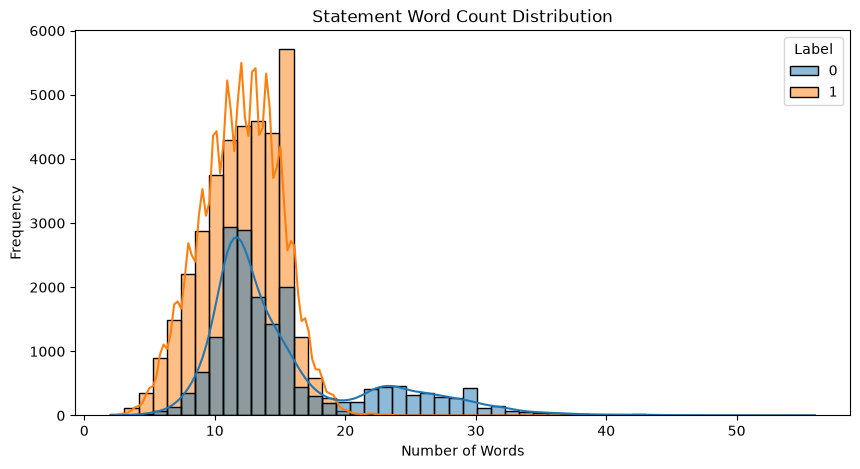

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="word_count",hue="Label",bins=50,kde=True)

plt.title("Statement Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [10]:
from collections import Counter

In [11]:
all_words = " ".join(df["Statement"]).split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('in', 19745),
 ('to', 19254),
 ('of', 16678),
 ('s', 14542),
 ('fact', 10297),
 ('check', 9841),
 ('for', 8934),
 ('on', 7900),
 ('the', 6520),
 ('not', 6231),
 ('a', 6184),
 ('is', 6110),
 ('as', 5498),
 ('india', 5091),
 ('from', 4949),
 ('with', 4866),
 ('bjp', 4559),
 ('video', 4448),
 ('modi', 4442),
 ('covid', 4403)]

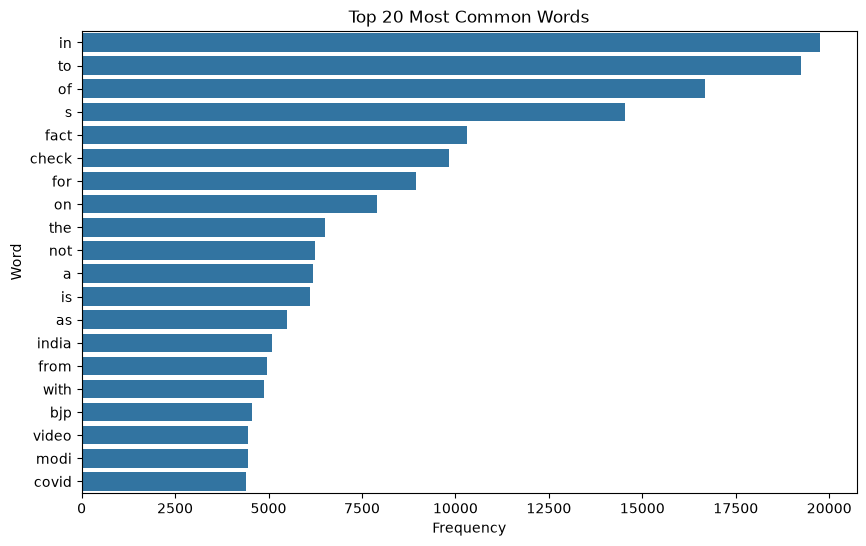

In [12]:
common_words = pd.DataFrame(word_counts.most_common(20),columns=["Word", "Frequency"])

plt.figure(figsize=(10, 6))

sns.barplot(data=common_words,x="Frequency",y="Word")

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [13]:
fake_text = " ".join(df[df["Label"] == 0]["Statement"])

true_text = " ".join(df[df["Label"] == 1]["Statement"])

fake_words = Counter(fake_text.split())
true_words = Counter(true_text.split())

In [14]:
fake_common = pd.DataFrame(fake_words.most_common(20),columns=["Word", "Frequency"])

display(fake_common)

,Word,Frequency
0,fact,10289
1,check,9692
2,of,8516
3,in,6647
4,s,5966
5,not,5118
6,the,4887
7,is,4791
8,to,4412
9,video,4281


In [15]:
true_common = pd.DataFrame(true_words.most_common(20),columns=["Word", "Frequency"])

display(true_common)

,Word,Frequency
0,to,14842
1,in,13098
2,s,8576
3,of,8162
4,for,6870
5,on,5303
6,india,3648
7,covid,3414
8,bjp,3366
9,at,2719
